In [0]:
%tensorflow_version 2.x  #First line always

`%tensorflow_version` only switches the major version: `1.x` or `2.x`.
You set: `2.x  #First line always`. This will be interpreted as: `2.x`.


TensorFlow is already loaded. Please restart the runtime to change versions.


Reference for tutorials/articles : 


*   http://blog.ai.ovgu.de/posts/jens/2019/002_tf20_basic_mnist/index.html
*   https://www.ritchievink.com/blog/2017/07/10/programming-a-neural-network-from-scratch/






In [0]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from datasets import MNISTDataset

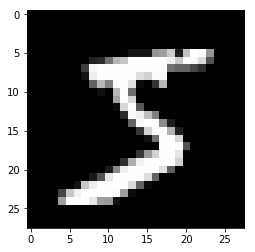

In [0]:
mnist = tf.keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

plt.imshow(train_images[0], cmap="Greys_r")

data = MNISTDataset(train_images.reshape([-1, 784]), train_labels, 
                    test_images.reshape([-1, 784]), test_labels,
                    batch_size=128)

In [0]:
train_steps = 1000
learning_rate = 0.1

W = tf.Variable(np.zeros([784, 10]).astype(np.float32))
b = tf.Variable(np.zeros(10, dtype=np.float32))

In [0]:
for step in range(train_steps):
    img_batch, lbl_batch = data.next_batch()
    with tf.GradientTape() as tape:
        logits = tf.matmul(img_batch, W) + b
        xent = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(logits=logits, labels=lbl_batch))
        
    grads = tape.gradient(xent, [W, b])
    W.assign_sub(learning_rate * grads[0])
    b.assign_sub(learning_rate * grads[1])
    
    if not step % 100:
        preds = tf.argmax(logits, axis=1, output_type=tf.int32)
        acc = tf.reduce_mean(tf.cast(tf.equal(preds, lbl_batch),tf.float32))
        print("epoch:{} / {}".format(step,train_steps)+"Loss: {} Accuracy: {}".format(xent, acc))

epoch:0 / 1000Loss: 0.31466615200042725 Accuracy: 0.9453125
epoch:100 / 1000Loss: 0.33586132526397705 Accuracy: 0.890625
epoch:200 / 1000Loss: 0.2775665521621704 Accuracy: 0.921875
epoch:300 / 1000Loss: 0.2716293931007385 Accuracy: 0.8984375
Starting new epoch...
epoch:400 / 1000Loss: 0.5282680988311768 Accuracy: 0.890625
epoch:500 / 1000Loss: 0.38537830114364624 Accuracy: 0.8828125
epoch:600 / 1000Loss: 0.3511958122253418 Accuracy: 0.8828125
epoch:700 / 1000Loss: 0.3536510765552521 Accuracy: 0.8984375
epoch:800 / 1000Loss: 0.33318543434143066 Accuracy: 0.890625
Starting new epoch...
epoch:900 / 1000Loss: 0.2445027083158493 Accuracy: 0.9296875


In [0]:
test_preds = tf.argmax(tf.matmul(data.test_data, W) + b, axis=1,
                       output_type=tf.int32)
acc = tf.reduce_mean(tf.cast(tf.equal(test_preds, data.test_labels),
                             tf.float32))
print(acc)

tf.Tensor(0.91, shape=(), dtype=float32)


## Network Parameters

In [0]:
#Network parameters
input_layer = 784    #24x24 images flattened
output_layer = 10
learning_rate = 0.1

#The structure of network is determined by 'dimensions' parameter in Network constructor


## Network structure

In [0]:
class Network:
  
  def update_weights(self, index, gradient):
        self.w[index].assign_sub(self.learning_rate * gradient)
        
  def update_bias(self, index, gradient):
        self.b[index].assign_sub(self.learning_rate * gradient)        
        
  def __init__(self, dimensions, learning_rate):
       # "dimensions" is the dimension of the network. (input, hidden layers, output)
       # Example if there are 5 inputs, 10 units hidden layer1, 5 units in hidden layer2 , 3 outputs dimenstion = (5,10,10,3)
       # "activations" is for activation funtion 
      
    self.dimen = dimensions
    self.no_of_layers = len(dimensions)
    self.loss = None
    self.learning_rate = learning_rate

    # Weights and biases 
    self.w = {}
    self.b = {}
    self.activation = {}

    for i in range(len(dimensions) - 1):
      self.b[i + 1] = tf.Variable(np.zeros(dimensions[i + 1], dtype=np.float32))# bias initialised to zero
      self.w[i + 1] = tf.Variable(tf.random.normal([dimensions[i], dimensions[i + 1]], 0, .1)) #weights initialised to random normal between -0.3 and 0.3

      #             self.activationFuction[i] = activations[i]
           
  
                                                                                                                           

# NOTE 
Initialisation should be random, because if all weights are initialised to 1 or worse 0, the hidden layer units will all be the same, which defeats the purpose of learning different features 



## Training

In [0]:

def train(net, train_steps): 
  for step in range(train_steps):
      img_batch, lbl_batch = data.next_batch()
      parameters =[]
      with tf.GradientTape() as tape:
          hidden_layer = img_batch # just for first iteration i
          for layer in range(len(net.dimen) - 2): #If dimension is 4, hidden layers = 2, 1 input 1 output layer
              hidden_layer = tf.nn.relu(tf.matmul(hidden_layer, net.w[layer+1]) + net.b[layer+1])
              parameters.append(net.w[layer+1]) # each hidden layer has 2 parameters: weight and bias
              parameters.append(net.b[layer+1])
   
          last_layer_index = len(net.dimen)-1 # last layer after all hidden layers is output layer
          parameters.append(net.w[last_layer_index])
          parameters.append(net.b[last_layer_index]) # always 10 in our case
          logits = tf.nn.sigmoid(tf.matmul(hidden_layer, net.w[last_layer_index]) + net.b[last_layer_index])
          xent = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(logits=logits, labels=lbl_batch))
         
      grads = tape.gradient(xent, parameters)
      for param_index in range(1,len(parameters),2):
        net.update_weights(param_index//2 + 1,grads[param_index-1])
        net.update_bias(param_index//2 + 1,grads[param_index])
#         net.update_weights(2,grads[2])
#         net.update_bias(2,grads[3])
#         net.update_weights(3,grads[4])
#         net.update_bias(3,grads[5])
#       net.w[1].assign_sub(learning_rate * grads[0])
#       net.b[1].assign_sub(learning_rate * grads[1])
#       net.w[2].assign_sub(learning_rate * grads[2])
#       net.b[2].assign_sub(learning_rate * grads[3])
#       net.w[3].assign_sub(learning_rate * grads[4])
#       net.b[3].assign_sub(learning_rate * grads[5])


   
      if not step % 100:
        preds = tf.argmax(logits, axis=1, output_type=tf.int32)
        acc = tf.reduce_mean(tf.cast(tf.equal(preds, lbl_batch),tf.float32))
        print("epoch:{} / {}".format(step,train_steps)+" Loss: {} Accuracy: {}".format(xent, acc))

# NOTE:
Even though the training module is made generic, it can be more generalised. Selecting of activation function just by passing as parameter, instead of manually changing would be better feature( as in kera ;-)).

## Testing

In [0]:
def test(net):
    print("Testing")
    hidden_layer = data.test_data # just for first iteration i
    for layer in range(len(net.dimen) - 2): #If dimension is 4, hidden layers = 2, 1 input 1 output layer
      hidden_layer = tf.nn.relu(tf.matmul(hidden_layer, net.w[layer+1]) + net.b[layer+1])
           
    last_layer_index = len(net.dimen)-1 # last layer after all hidden layers is output layer
    logits = tf.nn.sigmoid(tf.matmul(hidden_layer, net.w[last_layer_index]) + net.b[last_layer_index])
    test_preds = tf.argmax(logits, axis=1, output_type=tf.int32)

    acc = tf.reduce_mean(tf.cast(tf.equal(test_preds, data.test_labels),tf.float32))
    print("Test accuracy: {}".format(acc))

## Execution

In [0]:
#Single- hidden layer
net = Network((784,256, 10), learning_rate)
train(net, 1000)
test(net)

epoch:0 / 1000Loss: 2.3382630348205566 Accuracy: 0.125
epoch:100 / 1000Loss: 1.8225367069244385 Accuracy: 0.765625
epoch:200 / 1000Loss: 1.743665337562561 Accuracy: 0.8203125
Starting new epoch...
epoch:300 / 1000Loss: 1.680572271347046 Accuracy: 0.875
epoch:400 / 1000Loss: 1.6613788604736328 Accuracy: 0.8671875
epoch:500 / 1000Loss: 1.6815242767333984 Accuracy: 0.8046875
epoch:600 / 1000Loss: 1.6479699611663818 Accuracy: 0.859375
epoch:700 / 1000Loss: 1.5953257083892822 Accuracy: 0.9453125
Starting new epoch...
epoch:800 / 1000Loss: 1.621675968170166 Accuracy: 0.859375
epoch:900 / 1000Loss: 1.6229913234710693 Accuracy: 0.8671875
Testing
Test accuracy: 0.8907999992370605


In [0]:
#2-hidden layers  (each hidden layer = 256)
net = Network((784, 256,256, 10), learning_rate)
train(net, 1000)
test(net)

epoch:0 / 1000Loss: 2.3902690410614014 Accuracy: 0.078125
epoch:100 / 1000Loss: 1.729784607887268 Accuracy: 0.8359375
epoch:200 / 1000Loss: 1.7059071063995361 Accuracy: 0.7578125
epoch:300 / 1000Loss: 1.6663200855255127 Accuracy: 0.8671875
Starting new epoch...
epoch:400 / 1000Loss: 1.6304028034210205 Accuracy: 0.84375
epoch:500 / 1000Loss: 1.641160249710083 Accuracy: 0.84375
epoch:600 / 1000Loss: 1.6092596054077148 Accuracy: 0.84375
epoch:700 / 1000Loss: 1.580605149269104 Accuracy: 0.90625
Starting new epoch...
epoch:800 / 1000Loss: 1.5849361419677734 Accuracy: 0.9140625
epoch:900 / 1000Loss: 1.5707886219024658 Accuracy: 0.90625
Testing
Test accuracy: 0.9121999740600586


In [0]:
#2-hidden layers (each hidden layer = 64)
net = Network((784, 64,64, 10), learning_rate)
train(net, 1000)
test(net)

epoch:0 / 1000 Loss: 2.3068432807922363 Accuracy: 0.1328125
epoch:100 / 1000 Loss: 2.0931053161621094 Accuracy: 0.6796875
Starting new epoch...
epoch:200 / 1000 Loss: 1.8474409580230713 Accuracy: 0.7578125
epoch:300 / 1000 Loss: 1.7864084243774414 Accuracy: 0.7109375
epoch:400 / 1000 Loss: 1.715631365776062 Accuracy: 0.7421875
epoch:500 / 1000 Loss: 1.6805479526519775 Accuracy: 0.84375
epoch:600 / 1000 Loss: 1.6550058126449585 Accuracy: 0.796875
Starting new epoch...
epoch:700 / 1000 Loss: 1.6379293203353882 Accuracy: 0.7890625
epoch:800 / 1000 Loss: 1.65440034866333 Accuracy: 0.8046875
epoch:900 / 1000 Loss: 1.634909987449646 Accuracy: 0.84375
Testing
Test accuracy: 0.8644999861717224


In [0]:
#2-hidden layers  (each hidden layer = 16)
net = Network((784, 16,16, 10), learning_rate)
train(net, 1000)
test(net)

epoch:0 / 1000 Loss: 2.304661750793457 Accuracy: 0.0546875
epoch:100 / 1000 Loss: 2.2998147010803223 Accuracy: 0.1015625
Starting new epoch...
epoch:200 / 1000 Loss: 2.2838497161865234 Accuracy: 0.2109375
epoch:300 / 1000 Loss: 2.2088282108306885 Accuracy: 0.265625
epoch:400 / 1000 Loss: 2.121147871017456 Accuracy: 0.3125
epoch:500 / 1000 Loss: 1.9284619092941284 Accuracy: 0.6640625
epoch:600 / 1000 Loss: 1.8707554340362549 Accuracy: 0.5546875
Starting new epoch...
epoch:700 / 1000 Loss: 1.7853642702102661 Accuracy: 0.5859375
epoch:800 / 1000 Loss: 1.8052732944488525 Accuracy: 0.515625
epoch:900 / 1000 Loss: 1.764128565788269 Accuracy: 0.53125
Testing
Test accuracy: 0.5554999709129333


## FASHION MNIST


4423680/4422102 [==============================] - 0s 0us/step
9


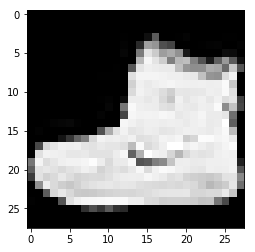

In [0]:
from datasets import MNISTDataset
mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print(train_labels[0])
plt.imshow(train_images[0], cmap="Greys_r")

data = MNISTDataset(train_images.reshape([-1, 784]), train_labels, 
                    test_images.reshape([-1, 784]), test_labels,
                    batch_size=128)

In [0]:
#Single- hidden layer
net = Network((784,256, 10), learning_rate)
train(net, 1000)
test(net)

epoch:0 / 1000 Loss: 2.316951274871826 Accuracy: 0.1328125
epoch:100 / 1000 Loss: 1.8071850538253784 Accuracy: 0.6953125
epoch:200 / 1000 Loss: 1.7376452684402466 Accuracy: 0.65625
epoch:300 / 1000 Loss: 1.680037021636963 Accuracy: 0.7734375
epoch:400 / 1000 Loss: 1.6758475303649902 Accuracy: 0.7578125
Starting new epoch...
epoch:500 / 1000 Loss: 1.6582006216049194 Accuracy: 0.7890625
epoch:600 / 1000 Loss: 1.697675108909607 Accuracy: 0.7109375
epoch:700 / 1000 Loss: 1.633351445198059 Accuracy: 0.75
epoch:800 / 1000 Loss: 1.671844244003296 Accuracy: 0.7109375
epoch:900 / 1000 Loss: 1.6613178253173828 Accuracy: 0.7265625
Starting new epoch...
Testing
Test accuracy: 0.7468000054359436


In [0]:
#2-hidden layers  (each hidden layer = 256)
net = Network((784, 256,256, 10), learning_rate)
train(net, 1000)
test(net)

epoch:0 / 1000 Loss: 2.347555637359619 Accuracy: 0.09375
epoch:100 / 1000 Loss: 1.7300267219543457 Accuracy: 0.7109375
epoch:200 / 1000 Loss: 1.6961660385131836 Accuracy: 0.765625
epoch:300 / 1000 Loss: 1.6610512733459473 Accuracy: 0.7421875
epoch:400 / 1000 Loss: 1.6618342399597168 Accuracy: 0.7265625
Starting new epoch...
epoch:500 / 1000 Loss: 1.6186445951461792 Accuracy: 0.765625
epoch:600 / 1000 Loss: 1.6216766834259033 Accuracy: 0.75
epoch:700 / 1000 Loss: 1.6367979049682617 Accuracy: 0.75
epoch:800 / 1000 Loss: 1.6199495792388916 Accuracy: 0.7421875
Starting new epoch...
epoch:900 / 1000 Loss: 1.6258362531661987 Accuracy: 0.7734375
Testing
Test accuracy: 0.7591000199317932


In [0]:
#2-hidden layers  (each hidden layer = 16)
net = Network((784, 16,16, 10), learning_rate)
train(net, 1000)
test(net)

epoch:0 / 1000 Loss: 2.3063573837280273 Accuracy: 0.109375
epoch:100 / 1000 Loss: 2.248960018157959 Accuracy: 0.09375
epoch:200 / 1000 Loss: 2.0813488960266113 Accuracy: 0.328125
epoch:300 / 1000 Loss: 1.8637149333953857 Accuracy: 0.34375
Starting new epoch...
epoch:400 / 1000 Loss: 1.8411602973937988 Accuracy: 0.28125
epoch:500 / 1000 Loss: 1.7578654289245605 Accuracy: 0.328125
epoch:600 / 1000 Loss: 1.790649652481079 Accuracy: 0.3046875
epoch:700 / 1000 Loss: 1.8016868829727173 Accuracy: 0.2578125
epoch:800 / 1000 Loss: 1.7758562564849854 Accuracy: 0.2734375
Starting new epoch...
epoch:900 / 1000 Loss: 1.7465906143188477 Accuracy: 0.28125
Testing
Test accuracy: 0.2623000144958496


## Observations


1.   Using 'tf.random.normal' by default gives higher value initialisation. Fixing value between -0.1 and 0.1(by giving mean = 0, sd = 0.1) gave quicker results with better accuracy

2.   More the layer/parameters more the epochs/runtime to get higher accuracy

3. Accuracy decreased with lesser parameters/features for same number of training steps


